# moa_actuator 패키지 기능 테스트

통합 패키지 `moa_actuator`의 핵심 기능을 AEDT 없이 검증합니다.

| # | 테스트 | 설명 |
|---|--------|------|
| 1 | Parser | `.dsa` / `.dsa3d` 파일 파싱 |
| 2 | Geometry | 형상 추출 + 좌표 확인 |
| 3 | Mapping | 재질 매핑 + 자석 방향 |
| 4 | Profiles | 프로필 로드 / 목록 |
| 5 | Solver dry-run | Maxwell 백엔드 커맨드 생성 (AEDT 불필요) |
| 6 | CLI | 명령줄 인터페이스 동작 |
| 7 | 3D revolve 로직 | 2D→3D 확인 |

In [3]:
import sys
from pathlib import Path

# moa_actuator가 있는 레포 루트를 path에 추가
REPO_ROOT = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import moa_actuator
print(f"moa_actuator loaded from: {moa_actuator.__file__}")
print(f"Public API: {moa_actuator.__all__}")

moa_actuator loaded from: e:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\moa_actuator\__init__.py
Public API: ['DesignModel', 'NodeModel', 'TestModel', 'parse_dosa_file', 'Geometry2D', 'extract_geometry', 'geometry_from_coil_params', 'resolve_material', 'resolve_magnet_direction', 'MaterialInfo']


## 1. 파서 테스트 — Solenoid & VCM (.dsa)

In [4]:
from moa_actuator import parse_dosa_file

SAMPLE_DIR = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA/DoSA-2D/Code/11_DoSA-2D/DoSA-2D/Samples")

design_sol = parse_dosa_file(SAMPLE_DIR / "Solenoid/Solenoid.dsa")
design_vcm = parse_dosa_file(SAMPLE_DIR / "VCM/VCM.dsa")

print("=== Solenoid ===")
print(f"  source_type: {design_sol.source_type}")
print(f"  Parts ({len(design_sol.parts)}): {[p.name for p in design_sol.parts]}")
print(f"  Tests ({len(design_sol.tests)}): {[t.name for t in design_sol.tests]}")

print("\n=== VCM ===")
print(f"  source_type: {design_vcm.source_type}")
print(f"  Parts ({len(design_vcm.parts)}): {[p.name for p in design_vcm.parts]}")
print(f"  Tests ({len(design_vcm.tests)}): {[t.name for t in design_vcm.tests]}")

=== Solenoid ===
  source_type: dsa
  Parts (4): ['coil', 'plunger', 'core', 'case']
  Tests (3): ['force', 'stroke', 'current']

=== VCM ===
  source_type: dsa
  Parts (4): ['coil', 'magnet', 'plate', 'yoke']
  Tests (3): ['force', 'stroke', 'current']


## 2. Geometry 추출 테스트

In [5]:
from moa_actuator import extract_geometry, Geometry2D

print("--- Solenoid parts geometry ---")
for part in design_sol.parts:
    geom = extract_geometry(part)
    if geom and geom.is_valid:
        print(f"  {part.name:10s} | type={geom.face_type:10s} | pts={len(geom.points)} "
              f"| W={geom.width:.2f}mm H={geom.height:.2f}mm")
        # 좌표 확인
        print(f"             | X=[{geom.min_x:.2f}, {geom.max_x:.2f}] Y=[{geom.min_y:.2f}, {geom.max_y:.2f}]")
    else:
        print(f"  {part.name:10s} | NO GEOMETRY")

--- Solenoid parts geometry ---
  coil       | type=RECTANGLE  | pts=4 | W=6.00mm H=16.00mm
             | X=[4.80, 10.80] Y=[-2.00, 14.00]
  plunger    | type=POLYGON    | pts=4 | W=4.00mm H=15.00mm
             | X=[0.00, 4.00] Y=[-15.00, 0.00]
  core       | type=POLYGON    | pts=6 | W=15.60mm H=18.00mm
             | X=[0.00, 15.60] Y=[1.20, 19.20]
  case       | type=POLYGON    | pts=6 | W=11.20mm H=25.20mm
             | X=[4.40, 15.60] Y=[-10.40, 14.80]


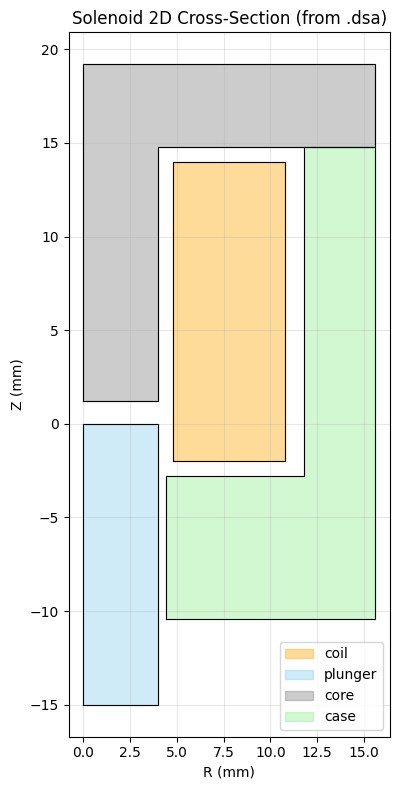

In [6]:
# 2D 단면 시각화 (matplotlib)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
colors = ['orange', 'skyblue', 'gray', 'lightgreen', 'salmon']

for i, part in enumerate(design_sol.parts):
    geom = extract_geometry(part)
    if geom and geom.is_valid:
        xs = [p.x for p in geom.points] + [geom.points[0].x]
        ys = [p.y for p in geom.points] + [geom.points[0].y]
        ax.fill(xs, ys, alpha=0.4, color=colors[i % len(colors)], label=part.name)
        ax.plot(xs, ys, 'k-', linewidth=0.8)

ax.set_xlabel('R (mm)')
ax.set_ylabel('Z (mm)')
ax.set_title('Solenoid 2D Cross-Section (from .dsa)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Material 매핑 테스트

In [7]:
from moa_actuator import resolve_material, resolve_magnet_direction
from moa_actuator.mapping import resolve_magnet_direction_3d

print("--- Solenoid materials ---")
for part in design_sol.parts:
    mat_name = part.properties.get('Material', 'Air')
    mat = resolve_material(mat_name)
    print(f"  {part.name:10s} | DoSA='{mat_name}' → Maxwell='{mat.maxwell_name}' ({mat.category})")

print("\n--- VCM materials + magnet direction ---")
for part in design_vcm.parts:
    mat_name = part.properties.get('Material', 'Air')
    mat = resolve_material(mat_name)
    info = f"  {part.name:10s} | '{mat_name}' → '{mat.maxwell_name}' ({mat.category})"
    if part.kind == 'Magnet':
        direction = part.properties.get('MagnetDirection', 'UP')
        vec2d = resolve_magnet_direction(direction)
        info += f" | dir={direction} → vec2d={vec2d}"
    print(info)

# 3D 방향 테스트
print("\n--- 3D magnet direction (rotation) ---")
for axis, angle in [("Y", 0), ("Y", 90), ("Y", 180), ("Z", 45)]:
    vec = resolve_magnet_direction_3d(axis, angle)
    print(f"  axis={axis}, angle={angle:3d}° → vec3d=({vec[0]:.3f}, {vec[1]:.3f}, {vec[2]:.3f})")

--- Solenoid materials ---
  coil       | DoSA='Copper' → Maxwell='copper' (conductor)
  plunger    | DoSA='430 Stainless Steel' → Maxwell='stainless_steel' (steel)
  core       | DoSA='1010 Steel' → Maxwell='steel_1010' (steel)
  case       | DoSA='1010 Steel' → Maxwell='steel_1010' (steel)

--- VCM materials + magnet direction ---
  coil       | 'Copper' → 'copper' (conductor)
  magnet     | 'N52' → 'NdFe52' (magnet) | dir=UP → vec2d=(0.0, 1.0)
  plate      | '1010 Steel' → 'steel_1010' (steel)
  yoke       | '1010 Steel' → 'steel_1010' (steel)

--- 3D magnet direction (rotation) ---
  axis=Y, angle=  0° → vec3d=(0.000, 0.000, 1.000)
  axis=Y, angle= 90° → vec3d=(1.000, 0.000, 0.000)
  axis=Y, angle=180° → vec3d=(0.000, 0.000, -1.000)
  axis=Z, angle= 45° → vec3d=(0.707, 0.707, 0.000)


## 4. Profiles 테스트

In [8]:
from moa_actuator.profiles import list_profiles, get_profile, get_unified_plan_summary

print("=== Available Profiles ===")
for p in list_profiles():
    print(f"  {p['name']:20s} | {p['solution_type']:15s} | step={p['time_step']} stop={p['stop_time']} | {p['notes']}")

# 특정 프로필 로드
prof = get_profile("ws01_2020r1")
print(f"\nLoaded profile: {prof.name}")
print(f"  solution_type = {prof.solution_type}")
print(f"  time_step     = {prof.time_step}")
print(f"  stop_time     = {prof.stop_time}")
print(f"  source_pdf    = {prof.source_pdf}")

=== Available Profiles ===
  default              | MagnetostaticZ  | step=1ms stop=10ms | Safe baseline profile for early integration (2D axisymmetric about Z).
  ws01_2020r1          | TransientZ      | step=0.2ms stop=20ms | Workshop preset for actuator transient flow (2D axisymmetric about Z).
  le01_2020r1          | MagnetostaticZ  | step=1ms stop=5ms | Lecture preset for concept validation (2D axisymmetric about Z).
  coupling_1114_2014   | TransientZ      | step=0.2ms stop=20ms | 2014 coupling solenoid profile (2D axisymmetric about Z).
  tpc_1210_2014        | MagnetostaticZ  | step=1ms stop=5ms | 2014 TPC solenoid profile (2D axisymmetric about Z).

Loaded profile: ws01_2020r1
  solution_type = TransientZ
  time_step     = 0.2ms
  stop_time     = 20ms
  source_pdf    = MAXW_Actuator_2020R1_EN_WS01.pdf


In [9]:
# Unified Plan 상태
plan = get_unified_plan_summary()
print(f"Plan version: {plan['version']}")
print(f"Scope: {plan['scope']}")
print(f"\nMilestones:")
for m in plan['milestones']:
    icon = '✅' if m['status'] == 'completed' else '🔄' if m['status'] == 'in-progress' else '⬜'
    print(f"  {icon} {m['id']}: {m['title']} [{m['status']}]")

Plan version: 0.1.0
Scope: DoSA-2D/3D to Maxwell automation

Milestones:
  ✅ M1: schema and parser freeze [completed]
  ✅ M2: 2d dry-run with profile [completed]
  ✅ M3: 2d geometry mapping [completed]
  ⬜ M4: 3d step import and run [not-started]


## 5. Solver Dry-Run 테스트 (AEDT 불필요)

In [10]:
from moa_actuator.runner import RunConfig, run

# 2D Magnetostatic dry-run
config_2d = RunConfig(
    input_file=SAMPLE_DIR / "Solenoid/Solenoid.dsa",
    mode="2d",
    solver="maxwell",
    profile="default",
    dry_run=True,
)
result_2d = run(config_2d)

print(f"=== 2D Dry-Run Result ===")
print(f"  ok: {result_2d.ok}")
print(f"  mode: {result_2d.mode}")
print(f"  solver: {result_2d.solver}")
print(f"  commands: {len(result_2d.commands)}")
print(f"  errors: {result_2d.errors}")
print(f"\n  Command sequence:")
for i, cmd in enumerate(result_2d.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {cmd['args']}")

=== 2D Dry-Run Result ===
  ok: True
  mode: 2d
  solver: maxwell
  commands: 10
  errors: []

  Command sequence:
     1. create_polyline           | {'name': 'coil', 'points_count': 4, 'plane': 'XZ'}
     2. create_polyline           | {'name': 'plunger', 'points_count': 4, 'plane': 'XZ'}
     3. create_polyline           | {'name': 'core', 'points_count': 6, 'plane': 'XZ'}
     4. create_polyline           | {'name': 'case', 'points_count': 6, 'plane': 'XZ'}
     5. assign_material           | {'name': 'coil', 'material': 'copper'}
     6. assign_material           | {'name': 'plunger', 'material': 'stainless_steel'}
     7. assign_material           | {'name': 'core', 'material': 'steel_1010'}
     8. assign_material           | {'name': 'case', 'material': 'steel_1010'}
     9. assign_coil               | {'name': 'coil', 'turns': 1040, 'polarity': 'Positive'}
    10. create_setup              | {'solution_type': 'MagnetostaticZ'}


In [11]:
# 3D dry-run (revolve)
config_3d = RunConfig(
    input_file=SAMPLE_DIR / "Solenoid/Solenoid.dsa",
    mode="3d",
    solver="maxwell",
    profile="ws01_2020r1",
    dry_run=True,
)
result_3d = run(config_3d)

print(f"=== 3D Dry-Run Result ===")
print(f"  ok: {result_3d.ok}")
print(f"  commands: {len(result_3d.commands)}")
print(f"  errors: {result_3d.errors}")
print(f"\n  Command sequence (3D includes sweep_around_axis):")
for i, cmd in enumerate(result_3d.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {cmd['args']}")

=== 3D Dry-Run Result ===
  ok: True
  commands: 14
  errors: []

  Command sequence (3D includes sweep_around_axis):
     1. create_polyline           | {'name': 'coil', 'points_count': 4, 'plane': 'XY'}
     2. sweep_around_axis         | {'name': 'coil', 'axis': 'Z', 'angle': 360}
     3. create_polyline           | {'name': 'plunger', 'points_count': 4, 'plane': 'XY'}
     4. sweep_around_axis         | {'name': 'plunger', 'axis': 'Z', 'angle': 360}
     5. create_polyline           | {'name': 'core', 'points_count': 6, 'plane': 'XY'}
     6. sweep_around_axis         | {'name': 'core', 'axis': 'Z', 'angle': 360}
     7. create_polyline           | {'name': 'case', 'points_count': 6, 'plane': 'XY'}
     8. sweep_around_axis         | {'name': 'case', 'axis': 'Z', 'angle': 360}
     9. assign_material           | {'name': 'coil', 'material': 'copper'}
    10. assign_material           | {'name': 'plunger', 'material': 'stainless_steel'}
    11. assign_material           | {'name': '

In [12]:
# VCM dry-run (자석 포함 모델)
config_vcm = RunConfig(
    input_file=SAMPLE_DIR / "VCM/VCM.dsa",
    mode="2d",
    solver="maxwell",
    profile="le01_2020r1",
    dry_run=True,
)
result_vcm = run(config_vcm)

print(f"=== VCM 2D Dry-Run ===")
print(f"  ok: {result_vcm.ok}, commands: {len(result_vcm.commands)}")
for i, cmd in enumerate(result_vcm.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {cmd['args']}")

=== VCM 2D Dry-Run ===
  ok: True, commands: 10
     1. create_polyline           | {'name': 'coil', 'points_count': 4, 'plane': 'XZ'}
     2. create_polyline           | {'name': 'magnet', 'points_count': 4, 'plane': 'XZ'}
     3. create_polyline           | {'name': 'plate', 'points_count': 4, 'plane': 'XZ'}
     4. create_polyline           | {'name': 'yoke', 'points_count': 6, 'plane': 'XZ'}
     5. assign_material           | {'name': 'coil', 'material': 'copper'}
     6. assign_material           | {'name': 'magnet', 'material': 'NdFe52'}
     7. assign_material           | {'name': 'plate', 'material': 'steel_1010'}
     8. assign_material           | {'name': 'yoke', 'material': 'steel_1010'}
     9. assign_coil               | {'name': 'coil', 'turns': 120, 'polarity': 'Positive'}
    10. create_setup              | {'solution_type': 'MagnetostaticZ'}


### 5-1. FEMM Backend Dry-Run (pyfemm)

In [13]:
# FEMM 2D dry-run — Solenoid
config_femm = RunConfig(
    input_file=SAMPLE_DIR / "Solenoid/Solenoid.dsa",
    mode="2d",
    solver="femm",
    dry_run=True,
)
result_femm = run(config_femm)

print(f"=== FEMM 2D Dry-Run (Solenoid) ===")
print(f"  ok: {result_femm.ok}")
print(f"  solver: {result_femm.solver}")
print(f"  commands: {len(result_femm.commands)}")
print(f"  errors: {result_femm.errors}")
print(f"\n  Command sequence:")
for i, cmd in enumerate(result_femm.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {cmd['args']}")

=== FEMM 2D Dry-Run (Solenoid) ===
  ok: True
  solver: femm
  commands: 20
  errors: []

  Command sequence:
     1. openfemm                  | {}
     2. newdocument               | {'doctype': 0}
     3. mi_probdef                | {'freq': 0, 'units': 'millimeters', 'type': 'axi'}
     4. mi_getmaterial            | {'name': '1010 Steel'}
     5. mi_getmaterial            | {'name': '430 Stainless Steel'}
     6. mi_getmaterial            | {'name': 'Copper'}
     7. draw_polygon              | {'name': 'coil', 'points': 4, 'group': 0}
     8. draw_polygon              | {'name': 'plunger', 'points': 4, 'group': 1}
     9. draw_polygon              | {'name': 'core', 'points': 6, 'group': 0}
    10. draw_polygon              | {'name': 'case', 'points': 6, 'group': 0}
    11. mi_addcircprop            | {'name': 'Coil', 'current': 1000.0, 'type': 1}
    12. mi_setblockprop           | {'name': 'coil'}
    13. mi_setblockprop           | {'name': 'plunger'}
    14. mi_setblockprop 

In [14]:
# FEMM VCM dry-run (자석 포함 모델)
config_femm_vcm = RunConfig(
    input_file=SAMPLE_DIR / "VCM/VCM.dsa",
    mode="2d",
    solver="femm",
    dry_run=True,
)
result_femm_vcm = run(config_femm_vcm)

print(f"=== FEMM 2D Dry-Run (VCM) ===")
print(f"  ok: {result_femm_vcm.ok}, commands: {len(result_femm_vcm.commands)}")
for i, cmd in enumerate(result_femm_vcm.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {cmd['args']}")

=== FEMM 2D Dry-Run (VCM) ===
  ok: True, commands: 20
     1. openfemm                  | {}
     2. newdocument               | {'doctype': 0}
     3. mi_probdef                | {'freq': 0, 'units': 'millimeters', 'type': 'axi'}
     4. mi_getmaterial            | {'name': '1010 Steel'}
     5. mi_getmaterial            | {'name': 'NdFeB 52 MGOe'}
     6. mi_getmaterial            | {'name': 'Copper'}
     7. draw_polygon              | {'name': 'coil', 'points': 4, 'group': 1}
     8. draw_polygon              | {'name': 'magnet', 'points': 4, 'group': 0}
     9. draw_polygon              | {'name': 'plate', 'points': 4, 'group': 0}
    10. draw_polygon              | {'name': 'yoke', 'points': 6, 'group': 0}
    11. mi_addcircprop            | {'name': 'Coil', 'current': 1000.0, 'type': 1}
    12. mi_setblockprop           | {'name': 'coil'}
    13. mi_setblockprop           | {'name': 'magnet'}
    14. mi_setblockprop           | {'name': 'plate'}
    15. mi_setblockprop         

### 5-2. GetDP Backend Dry-Run (Gmsh + GetDP)

In [15]:
SAMPLE_3D_DIR = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA/DoSA-3D/Code/01_DoSA-3D/DoSA-3D/Samples")

design_sol3d = parse_dosa_file(SAMPLE_3D_DIR / "Solenoid/Solenoid.dsa3d")
design_vcm3d = parse_dosa_file(SAMPLE_3D_DIR / "VCM/VCM.dsa3d")

print(f"=== 3D Solenoid ===")
print(f"  Parts ({len(design_sol3d.parts)}): {[p.name for p in design_sol3d.parts]}")
print(f"  Tests ({len(design_sol3d.tests)}): {[t.name for t in design_sol3d.tests]}")
print(f"\n=== 3D VCM ===")
print(f"  Parts ({len(design_vcm3d.parts)}): {[p.name for p in design_vcm3d.parts]}")
print(f"  Tests ({len(design_vcm3d.tests)}): {[t.name for t in design_vcm3d.tests]}")

=== 3D Solenoid ===
  Parts (4): ['Coil', 'Armature', 'Core', 'Case']
  Tests (1): ['Force']

=== 3D VCM ===
  Parts (4): ['Coil', 'Magnet', 'Plate', 'Case']
  Tests (1): ['Force']


In [16]:
# GetDP 3D dry-run — Solenoid
config_getdp = RunConfig(
    input_file=SAMPLE_3D_DIR / "Solenoid/Solenoid.dsa3d",
    mode="3d",
    solver="getdp",
    dry_run=True,
    out_dir="./output/getdp_solenoid",
)
result_getdp = run(config_getdp)

print(f"=== GetDP 3D Dry-Run (Solenoid) ===")
print(f"  ok: {result_getdp.ok}")
print(f"  solver: {result_getdp.solver}")
print(f"  commands: {len(result_getdp.commands)}")
print(f"  errors: {result_getdp.errors}")
print(f"\n  Command sequence:")
for i, cmd in enumerate(result_getdp.commands, 1):
    print(f"    {i:2d}. {cmd['method']:20s} | {cmd['args']}")

=== GetDP 3D Dry-Run (Solenoid) ===
  ok: True
  solver: getdp
  commands: 4
  errors: []

  Command sequence:
     1. generate_geo         | {'path': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_solenoid\\model.geo', 'lines': 23}
     2. generate_pro         | {'path': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_solenoid\\model.pro', 'lines': 132}
     3. gmsh (dry-run)       | {'file': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_solenoid\\model.geo'}
     4. getdp (dry-run)      | {'file': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_solenoid\\model.pro'}


In [17]:
# GetDP 생성된 .geo / .pro 파일 내용 확인
from pathlib import Path

geo_path = Path("./output/getdp_solenoid/model.geo")
pro_path = Path("./output/getdp_solenoid/model.pro")

print("=== Generated .geo (first 30 lines) ===")
if geo_path.exists():
    lines = geo_path.read_text(encoding="utf-8").splitlines()
    for line in lines[:30]:
        print(f"  {line}")
    print(f"  ... ({len(lines)} lines total)")

print(f"\n=== Generated .pro (first 50 lines) ===")
if pro_path.exists():
    lines = pro_path.read_text(encoding="utf-8").splitlines()
    for line in lines[:50]:
        print(f"  {line}")
    print(f"  ... ({len(lines)} lines total)")

=== Generated .geo (first 30 lines) ===
  // Auto-generated by moa_actuator GetDP backend
  SetFactory("OpenCASCADE");
  
  mm = 1e-3;
  
  Mesh.Optimize = 1;
  Mesh.VolumeEdges = 0;
  
  // Part definitions
  COIL = 1;
  ARMATURE = 2;
  CORE = 3;
  CASE = 4;
  AIR = 199;
  SKIN_AIR = 399;
  SKIN_MOVING = 301;
  
  // 2D section revolve mode
  
  // Air region (to be refined per design)
  // volOuterBox = newv; Box(newv) = {...};
  // BooleanDifference for air region
  
  Mesh 3;
  ... (24 lines total)

=== Generated .pro (first 50 lines) ===
  // Auto-generated by moa_actuator GetDP backend
  
  // ===== Group =====
  Group {
      volAir = Region[199];
      skinAir = Region[399];
      skinMoving = Region[301];
  
      volCoil = Region[1];
      volArmature = Region[2];
      volCore = Region[3];
      volCase = Region[4];
  
      domainNL = Region[{ volArmature, volCore, volCase }];
      domainL = Region[{ volAir, volCoil }];
      domainALL = Region[{ domainNL, domainL }];
  }


In [18]:
# GetDP VCM 3D dry-run (자석 포함)
config_getdp_vcm = RunConfig(
    input_file=SAMPLE_3D_DIR / "VCM/VCM.dsa3d",
    mode="3d",
    solver="getdp",
    dry_run=True,
    out_dir="./output/getdp_vcm",
)
result_getdp_vcm = run(config_getdp_vcm)

print(f"=== GetDP 3D Dry-Run (VCM) ===")
print(f"  ok: {result_getdp_vcm.ok}, commands: {len(result_getdp_vcm.commands)}")
for i, cmd in enumerate(result_getdp_vcm.commands, 1):
    print(f"    {i:2d}. {cmd['method']:20s} | {cmd['args']}")

# VCM .pro 파일에서 자석 관련 Function 확인
pro_vcm = Path("./output/getdp_vcm/model.pro")
if pro_vcm.exists():
    text = pro_vcm.read_text(encoding="utf-8")
    print(f"\n=== VCM .pro — Magnet sections ===")
    for line in text.splitlines():
        if "Magnet" in line or "hc[" in line:
            print(f"  {line}")

=== GetDP 3D Dry-Run (VCM) ===
  ok: True, commands: 4
     1. generate_geo         | {'path': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_vcm\\model.geo', 'lines': 23}
     2. generate_pro         | {'path': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_vcm\\model.pro', 'lines': 134}
     3. gmsh (dry-run)       | {'file': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_vcm\\model.geo'}
     4. getdp (dry-run)      | {'file': 'E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\output\\getdp_vcm\\model.pro'}

=== VCM .pro — Magnet sections ===
      volMagnet = Region[2];
      domainL = Region[{ volAir, volCoil, volMagnet }];
      domainMagnet = Region[{ volMagnet }];
      // Magnet: Magnet
      hc[volMagnet] = Vector[-969969.00, -0.00, -0.00];
      mu[volMagnet] = 1.037798;
      nu[volMagnet] = 1.0/1.037798;


## 6. Solver Backend 인터페이스 확인

In [19]:
from moa_actuator.solvers import SolverBackend, MaxwellBackend
from moa_actuator.solvers.femm_backend import FemmBackend
from moa_actuator.solvers.getdp_backend import GetDPBackend

backends = [MaxwellBackend(), FemmBackend(), GetDPBackend()]

print("=== Registered Solver Backends ===")
for b in backends:
    print(f"  {b.name:10s} | modes={b.supported_modes} | is SolverBackend: {isinstance(b, SolverBackend)}")

# FEMM은 3D 미지원
result_femm_3d = FemmBackend().solve(design_sol, mode="3d", dry_run=True)
print(f"\nFEMM 3D attempt: ok={result_femm_3d.ok}, errors={result_femm_3d.errors}")

# GetDP는 2D 미지원
result_getdp_2d = GetDPBackend().solve(design_sol, mode="2d", dry_run=True)
print(f"GetDP 2D attempt: ok={result_getdp_2d.ok}, errors={result_getdp_2d.errors}")

=== Registered Solver Backends ===
  maxwell    | modes=['2d', '3d'] | is SolverBackend: True
  femm       | modes=['2d'] | is SolverBackend: True
  getdp      | modes=['3d'] | is SolverBackend: True

FEMM 3D attempt: ok=False, errors=['FEMM backend only supports 2D axisymmetric mode']
GetDP 2D attempt: ok=False, errors=['GetDP backend only supports 3D mode']


## 7. CLI 동작 테스트 (subprocess)

In [20]:
import subprocess, json

# inspect 명령
result = subprocess.run(
    [sys.executable, "-m", "moa_actuator", "inspect",
     "--input", str(SAMPLE_DIR / "Solenoid/Solenoid.dsa")],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print("=== CLI: inspect ===")
print(result.stdout)

# profiles 명령
result2 = subprocess.run(
    [sys.executable, "-m", "moa_actuator", "profiles"],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print("=== CLI: profiles ===")
profiles_data = json.loads(result2.stdout)
for p in profiles_data:
    print(f"  {p['name']:20s} | {p['solution_type']}")

# CLI: FEMM dry-run
result_cli_femm = subprocess.run(
    [sys.executable, "-m", "moa_actuator", "run",
     "--input", str(SAMPLE_DIR / "Solenoid/Solenoid.dsa"),
     "--solver", "femm", "--dry-run"],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print("\n=== CLI: FEMM dry-run ===")
print(result_cli_femm.stdout)

# CLI: GetDP dry-run
result_cli_getdp = subprocess.run(
    [sys.executable, "-m", "moa_actuator", "run",
     "--input", str(SAMPLE_3D_DIR / "Solenoid/Solenoid.dsa3d"),
     "--solver", "getdp", "--mode", "3d", "--dry-run"],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print("=== CLI: GetDP dry-run ===")
print(result_cli_getdp.stdout)

=== CLI: inspect ===
{
  "name": "",
  "source_file": "E:\\KDH\\gitDosa_Actuator\\MoaActuatorBasedOnDoSA\\DoSA-2D\\Code\\11_DoSA-2D\\DoSA-2D\\Samples\\Solenoid\\Solenoid.dsa",
  "source_type": "dsa",
  "node_count": 1,
  "part_count": 4,
  "test_count": 3,
  "parts": [
    {
      "name": "coil",
      "kind": "Coil"
    },
    {
      "name": "plunger",
      "kind": "Steel"
    },
    {
      "name": "core",
      "kind": "Steel"
    },
    {
      "name": "case",
      "kind": "Steel"
    }
  ],
  "tests": [
    {
      "name": "force",
      "kind": "ForceTest"
    },
    {
      "name": "stroke",
      "kind": "StrokeTest"
    },
    {
      "name": "current",
      "kind": "CurrentTest"
    }
  ]
}

=== CLI: profiles ===
  default              | MagnetostaticZ
  ws01_2020r1          | TransientZ
  le01_2020r1          | MagnetostaticZ
  coupling_1114_2014   | TransientZ
  tpc_1210_2014        | MagnetostaticZ

=== CLI: FEMM dry-run ===
{
  "ok": true,
  "mode": "2d",
  "solver": 

## 8. Geometry from Coil Parameters (fallback)

Shape 블록이 없는 코일도 `InnerDiameter/OuterDiameter/Height`로 지오메트리 생성 가능

In [21]:
from moa_actuator.geometry import geometry_from_coil_params, geometry_from_polygon_points

# 코일 파라미터로부터 직사각형 단면 생성
coil_geom = geometry_from_coil_params(
    name="TestCoil",
    inner_diameter=10.0,
    outer_diameter=20.0,
    height=15.0,
    base_y=-7.5,
)
print(f"Coil geometry: {coil_geom.name}")
print(f"  valid={coil_geom.is_valid}, face_type={coil_geom.face_type}")
print(f"  R=[{coil_geom.min_x:.1f}, {coil_geom.max_x:.1f}] Z=[{coil_geom.min_y:.1f}, {coil_geom.max_y:.1f}]")
print(f"  polyline_points: {coil_geom.to_polyline_points()}")

# 임의 폴리곤
custom = geometry_from_polygon_points("CustomPart", [(0, 0), (5, 0), (5, 10), (2, 12), (0, 10)])
print(f"\nCustom polygon: pts={len(custom.points)}, valid={custom.is_valid}")

Coil geometry: TestCoil
  valid=True, face_type=RECTANGLE
  R=[5.0, 10.0] Z=[-7.5, 7.5]
  polyline_points: [[5.0, -7.5, 0.0], [10.0, -7.5, 0.0], [10.0, 7.5, 0.0], [5.0, 7.5, 0.0]]

Custom polygon: pts=5, valid=True


## 9. SweepSettings & Setup 구조 확인

In [22]:
from moa_actuator.setup import SweepSettings
from dataclasses import asdict

sweep = SweepSettings()
print("Default SweepSettings:")
for k, v in asdict(sweep).items():
    print(f"  {k:25s} = {v}")

# 커스텀 스윕
sweep_custom = SweepSettings(
    amp_start=200, amp_stop=1000, amp_step=200,
    move_start=0, move_stop=6, move_step=2,
)
print(f"\nCustom sweep: Amp {sweep_custom.amp_start}~{sweep_custom.amp_stop} step {sweep_custom.amp_step}")
print(f"              Move {sweep_custom.move_start}~{sweep_custom.move_stop} step {sweep_custom.move_step}")

Default SweepSettings:
  amp_name                  = Amp_1
  amp_start                 = 500
  amp_stop                  = 2000
  amp_step                  = 500
  move_name                 = move
  move_start                = 0
  move_stop                 = 4
  move_step                 = 1
  parametric_setup_name     = ParametricSetup1

Custom sweep: Amp 200~1000 step 200
              Move 0~6 step 2


## 10. 전체 요약

| 기능 | 상태 | 비고 |
|------|------|------|
| `.dsa` 파싱 | ✅ | Solenoid, VCM 정상 |
| `.dsa3d` 파싱 | ✅ | Solenoid, VCM 3D 정상 |
| Geometry 추출 | ✅ | 2D polygon, coil params fallback |
| Material 매핑 | ✅ | steel, magnet, conductor |
| Magnet 3D direction | ✅ | rotation axis/angle |
| Profiles | ✅ | 5개 프리셋 |
| Maxwell dry-run 2D/3D | ✅ | commands 생성, revolve 포함 |
| Maxwell live 2D | ✅ | pyaedt 1.0.0rc2, AEDT Desktop |
| FEMM dry-run 2D | ✅ | 20 commands (Solenoid), pyfemm |
| FEMM live 2D | ✅ | pyfemm + C:\femm42 |
| FEMM sweep | ✅ | 전류/스트로크 sweep + 그래프 |
| GetDP dry-run 3D | ✅ | .geo/.pro 생성 |
| GetDP live 3D | ✅ | E:\onelab-Windows64 (gmsh+getdp) |
| CLI (inspect/run/profiles) | ✅ | 3개 solver 모두 지원 |
| GUI (PyQt6) | ⬜ | `python -m moa_actuator gui` |

## 11. Live 실행 테스트 — FEMM / Maxwell / GetDP

아래 셀들은 실제 솔버를 실행합니다. 각 솔버가 설치되어 있어야 합니다.
- **FEMM**: pyfemm + FEMM 4.2 (`C:\femm42`)
- **Maxwell**: pyaedt + AEDT Desktop 설치
- **GetDP**: gmsh + getdp 바이너리 (미설치 시 skip)

### 11-1. FEMM Live 실행 — Solenoid 2D

In [23]:
import sys
from pathlib import Path

REPO_ROOT = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from moa_actuator.parser import parse_dosa_file
from moa_actuator.runner import RunConfig, run
from moa_actuator.solvers.femm_backend import FemmBackend

SAMPLE_DIR = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA/DoSA-2D/Code/11_DoSA-2D/DoSA-2D/Samples")
SAMPLE_3D_DIR = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA/DoSA-3D/Code/01_DoSA-3D/DoSA-3D/Samples")

design_sol = parse_dosa_file(SAMPLE_DIR / "Solenoid/Solenoid.dsa")

# FEMM live 실행 (단일 전류점)
fb = FemmBackend()
result_femm_live = fb.solve(
    design_sol,
    mode="2d",
    out_dir="./output/femm_live_solenoid",
    dry_run=False,
    current=1000.0,
    stroke=0.0,
    mesh_size=1.0,
)

print(f"=== FEMM Live Result (Solenoid) ===")
print(f"  ok: {result_femm_live.ok}")
print(f"  solver: {result_femm_live.solver}")
print(f"  errors: {result_femm_live.errors}")
print(f"  project: {result_femm_live.project_path}")
print(f"  force_data: {result_femm_live.force_data}")

if result_femm_live.force_data:
    fd = result_femm_live.force_data[0]
    print(f"\n  >>> Force_Y = {fd['Force_Y']:.6f} N (at {fd['current']}A, stroke={fd['stroke']}mm)")

=== FEMM Live Result (Solenoid) ===
  ok: True
  solver: femm
  errors: []
  project: output\femm_live_solenoid\model.fem
  force_data: [{'current': 1000.0, 'stroke': 0.0, 'Force_Y': 3985.563317965351}]

  >>> Force_Y = 3985.563318 N (at 1000.0A, stroke=0.0mm)


In [ ]:
# FEMM live — 전류 sweep (여러 전류값에서 Force 측정)
result_femm_sweep = fb.solve_sweep(
    design_sol,
    out_dir="./output/femm_live_sweep",
    current_list=[200, 400, 600, 800, 1000],
    fixed_stroke=0.0,
    mesh_size=1.0,
)

print(f"=== FEMM Sweep Result ===")
print(f"  ok: {result_femm_sweep.ok}")
print(f"  errors: {result_femm_sweep.errors}")
print(f"  force points: {len(result_femm_sweep.force_data)}")
print()
if result_femm_sweep.force_data:
    print(f"  {'Current (A)':>12s}  {'Force_Y (N)':>12s}")
    print(f"  {'-'*12}  {'-'*12}")
    for fd in result_femm_sweep.force_data:
        print(f"  {fd['current']:12.1f}  {fd['Force_Y']:12.6f}")

In [ ]:
# FEMM sweep 결과 시각화
import matplotlib.pyplot as plt

if result_femm_sweep.force_data:
    currents = [fd["current"] for fd in result_femm_sweep.force_data]
    forces = [fd["Force_Y"] for fd in result_femm_sweep.force_data]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(currents, forces, "bo-", linewidth=2, markersize=8)
    ax.set_xlabel("Current (A)", fontsize=12)
    ax.set_ylabel("Force_Y (N)", fontsize=12)
    ax.set_title("FEMM Live — Solenoid Force vs Current", fontsize=14)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("No force data available for plotting")

### 11-2. Maxwell Live 실행 — Solenoid 2D

AEDT Desktop이 실행되어 있어야 합니다. `non_graphical=True`로 백그라운드 실행됩니다.

In [25]:
from moa_actuator.solvers.maxwell_backend import MaxwellBackend

mb = MaxwellBackend(
    aedt_version="2026.1",
    non_graphical=False,
    new_desktop=False,
    solution_type="MagnetostaticZ",
)

result_maxwell_live = mb.solve(
    design_sol,
    mode="2d",
    out_dir="./output/maxwell_live_solenoid",
    dry_run=False,
)

print(f"=== Maxwell Live Result (Solenoid 2D) ===")
print(f"  ok: {result_maxwell_live.ok}")
print(f"  solver: {result_maxwell_live.solver}")
print(f"  mode: {result_maxwell_live.mode}")
print(f"  commands: {len(result_maxwell_live.commands)}")
print(f"  errors: {result_maxwell_live.errors}")
print(f"  project: {result_maxwell_live.project_path}")
print(f"\n  Command sequence:")
for i, cmd in enumerate(result_maxwell_live.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {cmd['args']}")

PyAEDT INFO: Parsing E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\maxwell_live_solenoid\DoSA_Project.aedt.
PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Initializing Desktop session.
PyAEDT INFO: File E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\maxwell_live_solenoid\DoSA_Project.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: Found active AEDT gRPC session on port 50051.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 50051.
PyAEDT INFO: Project DoSA_Project has been opened.
PyAEDT INFO: Active Design set to DoSA_Project
PyAEDT INFO: AEDT objects correctly read
PyAEDT INFO: Modeler2D class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Materials class has been initialized!

### 11-3. GetDP Live 실행 — Solenoid 3D

`E:\onelab-Windows64\` 의 gmsh.exe, getdp.exe를 사용합니다.
> **참고**: GetDP 3D 실행에는 적절한 .geo에 STEP 파일이나 완전한 revolve geometry가 필요합니다.
> 현재 .geo 템플릿은 geometry scaffold만 생성하므로, 실행은 메시 생성 단계까지 테스트합니다.

In [28]:
import importlib
import moa_actuator.solvers.getdp_backend
importlib.reload(moa_actuator.solvers.getdp_backend)
from moa_actuator.solvers.getdp_backend import GetDPBackend

ONELAB_DIR = r"E:\onelab-Windows64"

gb = GetDPBackend(
    gmsh_exe=f"{ONELAB_DIR}\\gmsh.exe",
    getdp_exe=f"{ONELAB_DIR}\\getdp.exe",
)

design_sol3d = parse_dosa_file(SAMPLE_3D_DIR / "Solenoid/Solenoid.dsa3d")

result_getdp_live = gb.solve(
    design_sol3d,
    mode="3d",
    out_dir="./output/getdp_dosa3d_live",
    dry_run=False,
)

print(f"=== GetDP Live Result (Solenoid 3D — DoSA-3D wrapper) ===")
print(f"  ok: {result_getdp_live.ok}")
print(f"  solver: {result_getdp_live.solver}")
print(f"  commands: {len(result_getdp_live.commands)}")
print(f"  errors: {result_getdp_live.errors}")
print(f"  project: {result_getdp_live.project_path}")
print(f"  force_data: {result_getdp_live.force_data}")
print(f"\n  Command sequence:")
for i, cmd in enumerate(result_getdp_live.commands, 1):
    print(f"    {i:2d}. {cmd['method']:25s} | {str(cmd['args'])[:80]}")

=== GetDP Live Result (Solenoid 3D — DoSA-3D wrapper) ===
  ok: True
  solver: getdp
  commands: 6
  errors: []
  project: output\getdp_dosa3d_live\model.pro
  force_data: [{'Fx': -0.09647456829881562, 'Fy': 11.47137119175557, 'Fz': -0.01070603973384673}]

  Command sequence:
     1. generate_define_geo       | {'path': 'output\\getdp_dosa3d_live\\Define.geo'}
     2. generate_bh_pro           | {'path': 'output\\getdp_dosa3d_live\\BH.pro', 'materials': ['SUS_430']}
     3. generate_design_geo       | {'path': 'output\\getdp_dosa3d_live\\model.geo'}
     4. generate_design_pro       | {'path': 'output\\getdp_dosa3d_live\\model.pro'}
     5. gmsh                      | {'cmd': 'E:\\onelab-Windows64\\gmsh.exe -3 E:\\KDH\\gitDosa_Actuator\\MoaActuato
     6. getdp                     | {'cmd': 'E:\\onelab-Windows64\\getdp.exe E:\\KDH\\gitDosa_Actuator\\MoaActuatorB
